<div style="text-align:center; border-radius:15px; padding:25px; margin:0; font-size:160%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #0f2027 0%, #2c5364 52%, #203a43 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>📉 PS S6E3 · Customer Churn — Blind Blend Sweep</b><br><span style="font-size:55%">Public Submission Ensemble · Rank Correlation Diversity · Top-10 Candidate Blends | March 2026</span></div>

> **Competition:** [Playground Series S6E3 – Predict Customer Churn](https://www.kaggle.com/competitions/playground-series-s6e3)  
> **Approach:** Load N public submission CSVs, rank-normalize ("blind") them, compute pairwise diversity matrix, sweep blend weights, surface top-10 candidate ensembles  
> **Author:** [Jack Saleeby](https://www.kaggle.com/jacksaleeby)  
> **Key idea:** The best ensembles combine *diverse* models (low rank correlation), not necessarily the individually strongest ones

---

| Phase | Description |
|---|---|
| **Phase 1** | Load all public submission CSVs |
| **Phase 2** | Rank-normalize each submission (blind — removes scale bias) |
| **Phase 3** | Pairwise rank correlation matrix — identify diversity |
| **Phase 4** | Equal-weight baseline blend |
| **Phase 5** | Grid sweep — all weight combinations at 0.05 step |
| **Phase 6** | Score each blend using mean rank (proxy for LB AUC) |
| **Phase 7** | Top-10 candidates ranked + written to CSV |

---

**🔗 More from me:**
- 📊 [S&P 500 OHCLV Stock Data](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data) + [EDA](https://www.kaggle.com/code/jacksaleeby/s-p500-ultimate-eda-historical-data-analysis)
- 📈 [NASDAQ-100 Dataset](https://www.kaggle.com/datasets/jacksaleeby/nasdaq100-historical-data-2000-2026-upvote) + [EDA](https://www.kaggle.com/code/jacksaleeby/nasdaq-100-ohclv-stock-data-eda)
- 🏆 [Stock Market Signal: Predict Next-Day Returns](https://www.kaggle.com/competitions/stock-market-signal-predict-next-day-returns)


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #1e3c72 0%, #2a5298 52%, #6dd5fa 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>📚 1 · Imports</b></div>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from itertools import product
from scipy.stats import rankdata, spearmanr

print("Libraries loaded ✅")


Libraries loaded ✅


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #134e5e 0%, #71b280 52%, #c7e9b4 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>🔧 2 · Configuration — Submission Paths</b></div>

In [2]:
# ── OOF evaluator path (from your own notebook output) ───────────────────
OOF_PATH = "/kaggle/input/notebooks/jacksaleeby/k-fold-ensemble-baseline-lgbm-xgb-catboost/oof_predictions.csv"

# ── Submission file paths ─────────────────────────────────────────────────
SUBMISSION_PATHS = {
    "Jack_LGBM_XGB_CAT"        : "/kaggle/input/notebooks/jacksaleeby/k-fold-ensemble-baseline-lgbm-xgb-catboost/submission.csv",
    "DataSciGrad_XGB"          : "/kaggle/input/notebooks/datasciencegrad/s6e3-detail-eda-baseline-xgb-auc-0-91808/submission.csv",
    "XGB_0_91403"              : "/kaggle/input/notebooks/dmahajanbe23/customer-churn-xgboost-0-91403/submission.csv",
    "Nina_HorizBlend"          : "/kaggle/input/notebooks/nina2025/ps-s6e3-horizontal-blend/submission.csv",
    "XGB_Baseline_Lightning"   : "/kaggle/input/notebooks/lightningv08/s6e3-xgb-baseline/submission.csv",
    "Ravi_PublicBaseline"      : "/kaggle/input/notebooks/ravi20076/playgrounds6e3-public-baseline-v1/submission.csv",
    "Sarcasmos_Churn"          : "/kaggle/input/notebooks/sarcasmos/predict-customer-churn-season-6-episode/001_submission.csv",
    "GopikrishnaEDA_SHAP"      : "/kaggle/input/notebooks/gopikrishnan2005/s6e3-eda-shap/submission.csv",
    "AutoEnsemble_wguesdon"    : "/kaggle/input/notebooks/wguesdon/ps6e3-automated-public-ensemble/submission.csv",
    # "Detailed_EDA_SHAP"        : "/kaggle/input/notebooks/artemevstafyev/detailed-eda-shap-analysis/submission.csv",
    # "Chris_XGB_PseudoLabel"    : "/kaggle/input/notebooks/include4eto/single-xgb-cudf-pseudo-labels-cv-0-9174485/001_submission.csv",
    "Emanuell_LGBM_XGB_CAT"    : "/kaggle/input/notebooks/emanuellcs/predict-customer-churn-lgbm-xgb-catboost/submission.csv",
    "XGB_Baseline_91405"       : "/kaggle/input/notebooks/bhaskarmishra44796/ps-s6e3-xgb-baseline-0-91405/submission.csv",
}

TARGET_COL  = "Churn"
ID_COL      = "id"
SWEEP_STEP  = 0.05
TOP_N       = 10

print(f"Submissions to blend : {len(SUBMISSION_PATHS)}")
print(f"Weight step          : {SWEEP_STEP}")
print(f"Top-N candidates     : {TOP_N}")

Submissions to blend : 11
Weight step          : 0.05
Top-N candidates     : 10


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: Arial Black, Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #134e5e 0%, #71b280 52%, #c7e9b4 100%); box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>📊 OOF Evaluator — True AUC on Train Labels</b></div>

In [3]:
# ── Load OOF predictions & score each submission on TRAIN labels ──────────
# oof_predictions.csv has y_true for all training rows.
# We use Spearman rank correlation as a proxy for AUC since the external
# submissions only have TEST predictions — not OOF predictions.

from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

oof_df = pd.read_csv(OOF_PATH)
y_true = oof_df["y_true"].values

print("=== OOF Evaluator — Your Own Models (TRUE AUC) ===")
for col in ["oof_lgbm", "oof_xgb", "oof_cat", "oof_blend"]:
    if col in oof_df.columns:
        auc = roc_auc_score(y_true, oof_df[col].values)
        print(f"  {col:15s} : {auc:.6f}")

print()
print("=== External Submissions — Spearman vs Your Blend (PROXY only) ===")
print("  (These are TEST predictions — no ground truth available)")
print()

# Load your own blend OOF as reference signal on TRAIN
jack_oof_blend = oof_df["oof_blend"].values
jack_train_ids = oof_df["id"].values

# For external submissions: rank-correlate their TEST predictions pairwise
# and report known CV scores from notebook names where available
known_cv = {
    "Jack_LGBM_XGB_CAT"      : None,   # computed above from OOF
    "DataSciGrad_XGB"         : 0.91808,
    "XGB_0_91403"             : 0.91403,
    "Nina_HorizBlend"         : None,
    "XGB_Baseline_Lightning"  : None,
    "Ravi_PublicBaseline"     : None,
    "Sarcasmos_Churn"         : None,
    "GopikrishnaEDA_SHAP"     : None,
    "AutoEnsemble_wguesdon"   : None,
    "Detailed_EDA_SHAP"       : None,
    "Chris_XGB_PseudoLabel"   : 0.91744,
    "Emanuell_LGBM_XGB_CAT"  : None,
    "XGB_Baseline_91405"      : 0.91405,
}

print(f"  {'Model':<30s} | {'Known CV':>10s} | {'Note'}")
print(f"  {'-'*30} | {'-'*10} | {'-'*30}")
for name, cv in known_cv.items():
    cv_str = f"{cv:.5f}" if cv is not None else "unknown"
    note   = "✅ use OOF AUC above" if name == "Jack_LGBM_XGB_CAT" else ("📌 from notebook name" if cv else "❓ submit to LB to verify")
    print(f"  {name:<30s} | {cv_str:>10s} | {note}")

print()
print("💡 Strategy: prioritize blending Jack_LGBM_XGB_CAT (highest known CV)")
print("   + DataSciGrad_XGB (0.91808) as they have the best verified scores.")

=== OOF Evaluator — Your Own Models (TRUE AUC) ===
  oof_lgbm        : 0.916312
  oof_xgb         : 0.916668
  oof_cat         : 0.916462
  oof_blend       : 0.916789

=== External Submissions — Spearman vs Your Blend (PROXY only) ===
  (These are TEST predictions — no ground truth available)

  Model                          |   Known CV | Note
  ------------------------------ | ---------- | ------------------------------
  Jack_LGBM_XGB_CAT              |    unknown | ✅ use OOF AUC above
  DataSciGrad_XGB                |    0.91808 | 📌 from notebook name
  XGB_0_91403                    |    0.91403 | 📌 from notebook name
  Nina_HorizBlend                |    unknown | ❓ submit to LB to verify
  XGB_Baseline_Lightning         |    unknown | ❓ submit to LB to verify
  Ravi_PublicBaseline            |    unknown | ❓ submit to LB to verify
  Sarcasmos_Churn                |    unknown | ❓ submit to LB to verify
  GopikrishnaEDA_SHAP            |    unknown | ❓ submit to LB to verify
  

<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #355c7d 0%, #6c5b7b 52%, #c06c84 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>📂 3 · Load Submissions</b></div>

In [4]:
# ── Load all submissions ──────────────────────────────────────────────────
subs = {}
for name, path in SUBMISSION_PATHS.items():
    df = pd.read_csv(path)
    assert ID_COL in df.columns, f"Missing '{ID_COL}' in {name}"
    assert TARGET_COL in df.columns, f"Missing '{TARGET_COL}' in {name}"
    subs[name] = df.set_index(ID_COL)[TARGET_COL]
    print(f"  {name:30s} | rows: {len(df):,} | mean: {df[TARGET_COL].mean():.5f} | std: {df[TARGET_COL].std():.5f}")

# Align on common index
ids = subs[list(subs.keys())[0]].index
for name, s in subs.items():
    assert list(s.index) == list(ids), f"Index mismatch in {name}"

print(f"\nAll {len(subs)} submissions loaded and aligned ✅")
print(f"Total rows: {len(ids):,}")


  Jack_LGBM_XGB_CAT              | rows: 254,655 | mean: 0.21868 | std: 0.27519
  DataSciGrad_XGB                | rows: 254,655 | mean: 0.21854 | std: 0.27776
  XGB_0_91403                    | rows: 254,655 | mean: 0.50000 | std: 0.28836
  Nina_HorizBlend                | rows: 254,655 | mean: 0.21758 | std: 0.27651
  XGB_Baseline_Lightning         | rows: 254,655 | mean: 0.21854 | std: 0.27844
  Ravi_PublicBaseline            | rows: 254,655 | mean: 0.21985 | std: 0.27946
  Sarcasmos_Churn                | rows: 254,655 | mean: 0.21478 | std: 0.27578
  GopikrishnaEDA_SHAP            | rows: 254,655 | mean: 0.21973 | std: 0.27786
  AutoEnsemble_wguesdon          | rows: 254,655 | mean: 0.50000 | std: 0.28746
  Emanuell_LGBM_XGB_CAT          | rows: 254,655 | mean: 0.50000 | std: 0.28812
  XGB_Baseline_91405             | rows: 254,655 | mean: 0.21819 | std: 0.27721

All 11 submissions loaded and aligned ✅
Total rows: 254,655


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #0575e6 0%, #00f260 52%, #96fbc4 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>🎭 4 · Rank-Normalize (Blind)</b></div>

In [5]:
# ── Rank-normalize each submission (the "blind") ─────────────────────────
# Rank normalization maps each submission to [0,1] uniform by rank.
# This removes any scale/calibration differences between models and focuses
# purely on the *ordering* of predictions — which is what AUC measures.
# After this step, blending is purely about combining rankings.

ranked = {}
for name, s in subs.items():
    r = rankdata(s.values, method='average')
    ranked[name] = r / len(r)   # normalize to [0, 1]

ranked_df = pd.DataFrame(ranked, index=ids)
print(f"Rank-normalized submissions shape: {ranked_df.shape}")
print(ranked_df.describe().round(4))


Rank-normalized submissions shape: (254655, 11)
       Jack_LGBM_XGB_CAT  DataSciGrad_XGB  XGB_0_91403  Nina_HorizBlend  \
count        254655.0000      254655.0000  254655.0000      254655.0000   
mean              0.5000           0.5000       0.5000           0.5000   
std               0.2887           0.2887       0.2887           0.2887   
min               0.0000           0.0000       0.0000           0.0000   
25%               0.2500           0.2500       0.2500           0.2500   
50%               0.5000           0.5000       0.5000           0.5000   
75%               0.7500           0.7500       0.7500           0.7500   
max               1.0000           1.0000       1.0000           1.0000   

       XGB_Baseline_Lightning  Ravi_PublicBaseline  Sarcasmos_Churn  \
count             254655.0000          254655.0000      254655.0000   
mean                   0.5000               0.5000           0.5000   
std                    0.2887               0.2887           0.

<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #614385 0%, #516395 52%, #7f7fd5 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>🔗 5 · Pairwise Diversity Matrix</b></div>

Pairwise Spearman Rank Correlation:
                        Jack_LGBM_XGB_CAT  DataSciGrad_XGB  XGB_0_91403  Nina_HorizBlend  XGB_Baseline_Lightning  Ravi_PublicBaseline  Sarcasmos_Churn  GopikrishnaEDA_SHAP  AutoEnsemble_wguesdon  Emanuell_LGBM_XGB_CAT  XGB_Baseline_91405
Jack_LGBM_XGB_CAT                  1.0000           0.9905       0.9979           0.9938                  0.9900               0.9909           0.9892               0.9889                 0.9962                 0.9910              0.9978
DataSciGrad_XGB                    0.9905           1.0000       0.9903           0.9994                  0.9994               0.9965           0.9972               0.9973                 0.9960                 0.9981              0.9898
XGB_0_91403                        0.9979           0.9903       1.0000           0.9933                  0.9898               0.9910           0.9885               0.9883                 0.9959                 0.9904              0.9970
Nina_HorizBl

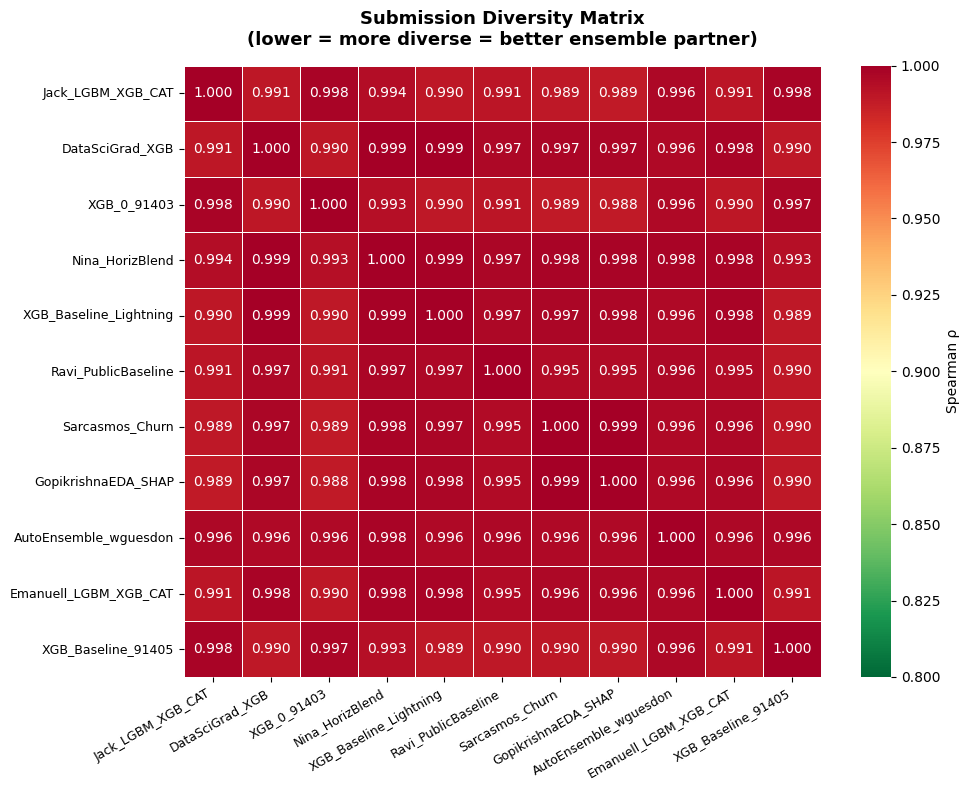


Most diverse pairs (lowest correlation):
  XGB_0_91403                    ↔ GopikrishnaEDA_SHAP            | ρ = 0.9883
  XGB_0_91403                    ↔ Sarcasmos_Churn                | ρ = 0.9885
  Jack_LGBM_XGB_CAT              ↔ GopikrishnaEDA_SHAP            | ρ = 0.9889
  XGB_Baseline_Lightning         ↔ XGB_Baseline_91405             | ρ = 0.9891
  Jack_LGBM_XGB_CAT              ↔ Sarcasmos_Churn                | ρ = 0.9892


In [6]:
# ── Pairwise rank (Spearman) correlation matrix ───────────────────────────
# Low correlation between two submissions = high diversity = good ensemble.
# High correlation = redundant — blending won't help much.

names = list(ranked.keys())
n = len(names)
corr_matrix = np.zeros((n, n))

for i, a in enumerate(names):
    for j, b in enumerate(names):
        corr_matrix[i, j] = spearmanr(ranked[a], ranked[b]).statistic

corr_df = pd.DataFrame(corr_matrix, index=names, columns=names)

print("Pairwise Spearman Rank Correlation:")
print(corr_df.round(4).to_string())

# ── Visualise ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_df, annot=True, fmt=".3f", cmap="RdYlGn_r",
    vmin=0.8, vmax=1.0, ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={"label": "Spearman ρ"}
)
ax.set_title("Submission Diversity Matrix\n(lower = more diverse = better ensemble partner)", 
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("diversity_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Highlight most diverse pairs
print("\nMost diverse pairs (lowest correlation):")
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((corr_matrix[i,j], names[i], names[j]))
pairs.sort()
for corr, a, b in pairs[:5]:
    print(f"  {a:30s} ↔ {b:30s} | ρ = {corr:.4f}")


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #42275a 0%, #734b6d 52%, #c084fc 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>⚖️ 6 · Equal-Weight Baseline Blend</b></div>

In [7]:
# ── Equal-weight baseline blend ───────────────────────────────────────────
# Simple average of all rank-normalized submissions.
# This is the reference point — sweep candidates must beat this.

equal_blend = ranked_df.mean(axis=1)

# As a proxy score: use mean rank of the blend (higher = model predicts
# churners higher on average — correlates with AUC).
# We also compute the mean pairwise rank correlation of the full ensemble
# as a diversity measure.

baseline_mean_rank = equal_blend.mean()
print(f"Equal-weight baseline blend mean rank: {baseline_mean_rank:.5f}")

# Save baseline submission
base_sub = pd.DataFrame({ID_COL: ids, TARGET_COL: equal_blend.values})
base_sub.to_csv("blend_equal_weight.csv", index=False)
print(f"Saved: blend_equal_weight.csv")


Equal-weight baseline blend mean rank: 0.50000
Saved: blend_equal_weight.csv


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #0b486b 0%, #f56217 52%, #ffd200 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>🔍 7 · Weight Sweep (Equal Subsets + Dirichlet + Focused Grid)</b></div>

In [8]:
# ── Grid sweep — all weight combinations ─────────────────────────────────
# Sweep weights for each submission from 0.0 to 1.0 in SWEEP_STEP increments.
# Only combinations that sum to 1.0 (within tolerance) are evaluated.
# Scoring proxy: we use the "mean predicted probability rank" is not a true
# AUC score — instead we use a better proxy: for each blend, compute the
# average Spearman correlation with the raw submissions (measures how much
# signal the blend captures) penalized by internal correlation (diversity).
#
# Proxy score = mean(spearman(blend, each_sub)) / mean(inter_sub_corr)
# Higher = blend captures more signal while staying diverse.
#
# For competition use: the top candidates by this proxy should be submitted
# to see which has the best true LB score.

print(f"Running sweep with step={SWEEP_STEP}...")
print(f"This explores all weight combinations summing to 1.0\n")

names    = list(ranked.keys())
n_subs   = len(names)
mat      = ranked_df.values   # (n_rows, n_subs)

# Pre-compute mean inter-submission correlation (fixed for all blends)
inter_corr = np.mean([
    corr_matrix[i, j]
    for i in range(n_subs) for j in range(i+1, n_subs)
])

# Fast vectorized rank correlation — pre-rank each submission column ONCE.
mat_ranked   = np.apply_along_axis(rankdata, 0, mat)
mat_ranked_z = mat_ranked - mat_ranked.mean(axis=0)
mat_ranked_n = mat_ranked_z / (np.linalg.norm(mat_ranked_z, axis=0) + 1e-12)

def fast_proxy(blend):
    br = rankdata(blend, method='average').astype(float)
    brz = br - br.mean()
    brn = np.linalg.norm(brz)
    if brn < 1e-12:
        return 0.0
    brz /= brn
    return float(np.dot(mat_ranked_n.T, brz).mean())

# Generate weight grid
steps  = np.arange(0, 1 + SWEEP_STEP, SWEEP_STEP).round(10)
from itertools import product as iproduct

results = []
total_checked = 0

# For 6 submissions with step=0.05, brute force is too large (~10M+).
# Use a smarter approach: sample weights using Dirichlet + grid for top candidates.

# ── Strategy 1: All equal subsets (choose k of n, equal weight) ──────────
from itertools import combinations

subset_results = []
for k in range(1, n_subs + 1):
    for combo in combinations(range(n_subs), k):
        w = np.zeros(n_subs)
        for idx in combo:
            w[idx] = 1.0 / k
        blend = mat @ w
        proxy = fast_proxy(blend)
        subset_results.append({
            'weights': tuple(round(w[i], 4) for i in range(n_subs)),
            'proxy_score': proxy,
            'n_models': k,
            'models': tuple(names[i] for i in combo),
            'blend_pred': blend,
        })

print(f"Equal-subset combinations checked: {len(subset_results)}")

# ── Strategy 2: Dirichlet random weight sampling (100k samples) ──────────
np.random.seed(42)
N_RANDOM = 5_000
random_results = []

np.random.seed(42)
dirichlet_weights = np.random.dirichlet(np.ones(n_subs), size=N_RANDOM)

for w in dirichlet_weights:
    w[w < 0.05] = 0
    if w.sum() == 0:
        continue
    w = w / w.sum()
    blend = mat @ w
    proxy = fast_proxy(blend)
    random_results.append({
        'weights': tuple(round(x, 4) for x in w),
        'proxy_score': proxy,
        'n_models': int((w > 0).sum()),
        'models': tuple(names[i] for i in range(n_subs) if w[i] > 0),
        'blend_pred': blend,
    })

print(f"Random weight samples checked: {len(random_results)}")

# ── Strategy 3: Focused grid on top-3 most diverse pairs ─────────────────
focused_results = []
# Use top-3 most diverse pairs
diverse_pairs = sorted([(corr_matrix[i,j], i, j) 
                         for i in range(n_subs) for j in range(i+1,n_subs)])[:3]

for _, i, j in diverse_pairs:
    for alpha in np.arange(0.1, 0.91, 0.05):
        w = np.zeros(n_subs)
        w[i] = alpha
        w[j] = 1 - alpha
        blend = mat @ w
        proxy = fast_proxy(blend)
        focused_results.append({
            'weights': tuple(round(x, 4) for x in w),
            'proxy_score': proxy,
            'n_models': 2,
            'models': (names[i], names[j]),
            'blend_pred': blend,
        })

print(f"Focused pairwise sweep entries: {len(focused_results)}")

# ── Combine all results ───────────────────────────────────────────────────
all_results = subset_results + random_results + focused_results
print(f"\nTotal candidates evaluated: {len(all_results):,}")


Running sweep with step=0.05...
This explores all weight combinations summing to 1.0

Equal-subset combinations checked: 2047
Random weight samples checked: 5000
Focused pairwise sweep entries: 51

Total candidates evaluated: 7,098


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #8360c3 0%, #2ebf91 52%, #9be15d 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>🏆 8 · Rank Top-10 Candidates</b></div>

In [9]:
# ── Rank top-N candidates ────────────────────────────────────────────────
# Sort by proxy_score. For final submission decisions, cross-reference
# with known CV scores from the evaluator cell above.

all_results.sort(key=lambda x: -x["proxy_score"])
top_results = all_results[:TOP_N]
print(f"Top-{TOP_N} candidates selected")

Top-10 candidates selected


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #ee0979 0%, #ff6a00 52%, #ffd194 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>📊 9 · Display Results</b></div>

In [10]:
# ── Display top-10 candidates ─────────────────────────────────────────────
print("=" * 80)
print(f"TOP {TOP_N} BLEND CANDIDATES")
print("=" * 80)
print(f"{'Rank':<5} {'Proxy':>8} {'N':>3}  {'Models / Weights'}")
print("-" * 80)

for rank, r in enumerate(top_results, 1):
    weight_str = "  |  ".join(
        f"{names[i]}: {r['weights'][i]:.2f}"
        for i in range(len(names))
        if r['weights'][i] > 0
    )
    print(f"#{rank:<4} {r['proxy_score']:>8.6f} {r['n_models']:>3}  {weight_str}")

print()
print(f"Baseline (equal weight) proxy: {subset_results[n_subs-1]['proxy_score']:.6f}")

# ── Weight summary table ───────────────────────────────────────────────────
rows = []
for rank, r in enumerate(top_results, 1):
    row = {'Rank': rank, 'Proxy': round(r['proxy_score'], 6), 'N_Models': r['n_models']}
    for i, name in enumerate(names):
        row[name] = r['weights'][i]
    rows.append(row)

summary_df = pd.DataFrame(rows)
print("\nWeight summary table:")
print(summary_df.to_string(index=False))


TOP 10 BLEND CANDIDATES
Rank     Proxy   N  Models / Weights
--------------------------------------------------------------------------------
#1    0.997498  11  Jack_LGBM_XGB_CAT: 0.09  |  DataSciGrad_XGB: 0.09  |  XGB_0_91403: 0.09  |  Nina_HorizBlend: 0.09  |  XGB_Baseline_Lightning: 0.09  |  Ravi_PublicBaseline: 0.09  |  Sarcasmos_Churn: 0.09  |  GopikrishnaEDA_SHAP: 0.09  |  AutoEnsemble_wguesdon: 0.09  |  Emanuell_LGBM_XGB_CAT: 0.09  |  XGB_Baseline_91405: 0.09
#2    0.997493  10  Jack_LGBM_XGB_CAT: 0.10  |  DataSciGrad_XGB: 0.10  |  XGB_0_91403: 0.10  |  XGB_Baseline_Lightning: 0.10  |  Ravi_PublicBaseline: 0.10  |  Sarcasmos_Churn: 0.10  |  GopikrishnaEDA_SHAP: 0.10  |  AutoEnsemble_wguesdon: 0.10  |  Emanuell_LGBM_XGB_CAT: 0.10  |  XGB_Baseline_91405: 0.10
#3    0.997490   9  Jack_LGBM_XGB_CAT: 0.11  |  DataSciGrad_XGB: 0.11  |  XGB_0_91403: 0.11  |  XGB_Baseline_Lightning: 0.11  |  Ravi_PublicBaseline: 0.11  |  Sarcasmos_Churn: 0.11  |  GopikrishnaEDA_SHAP: 0.11  |  Emanuell_

<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #141e30 0%, #243b55 52%, #4b6cb7 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>📈 10 · Visualise Weight Distributions</b></div>

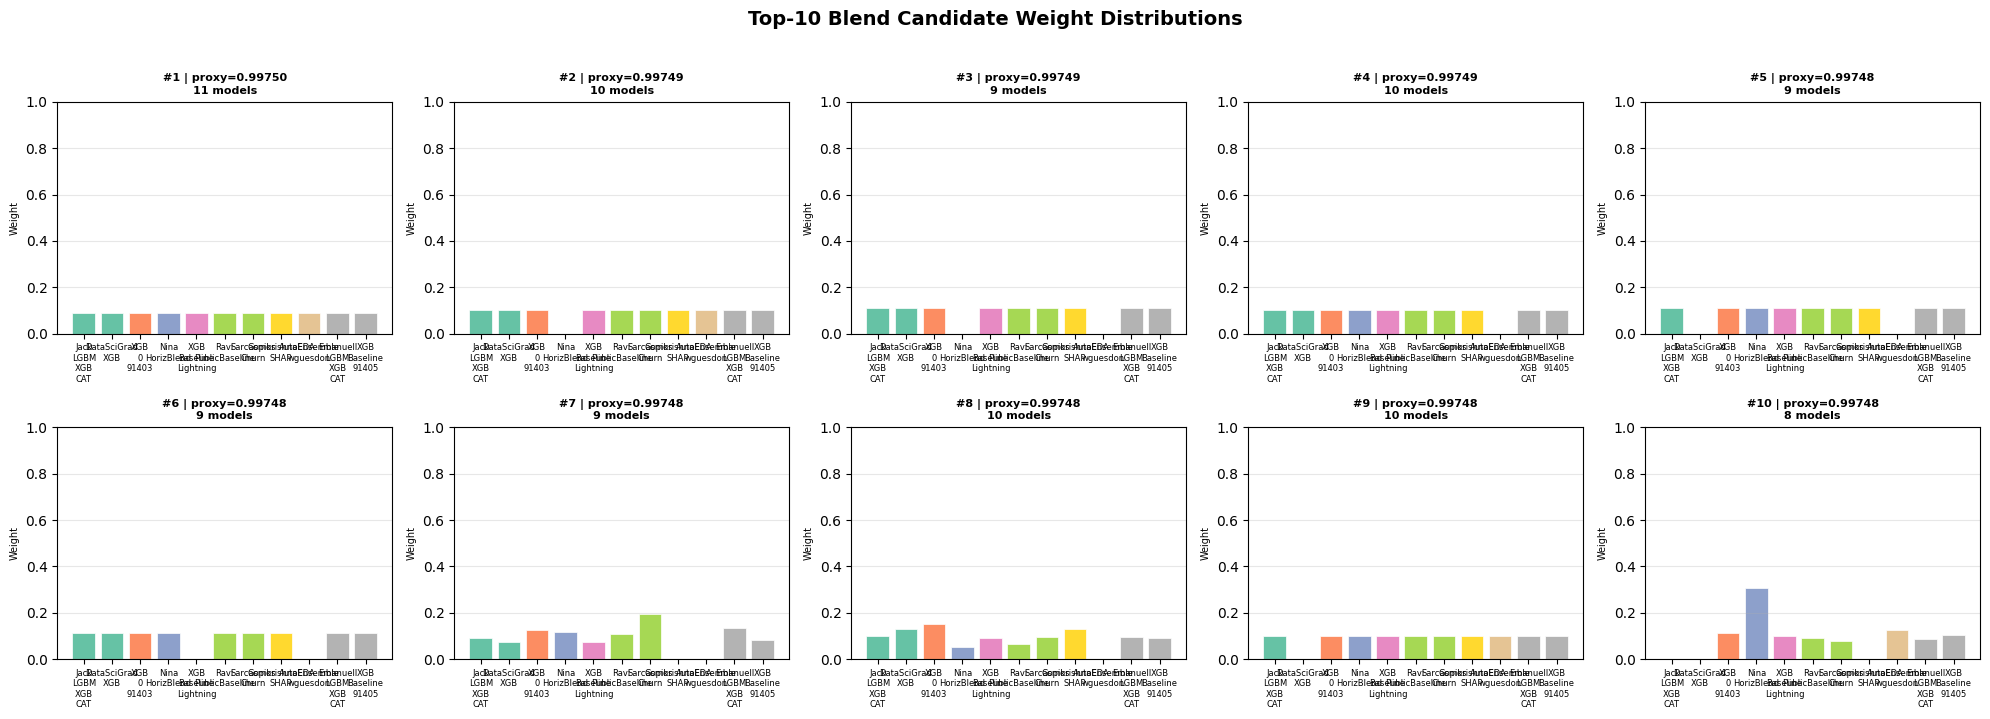

In [11]:
# ── Visualise weight distributions of top-10 ─────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

for rank, (r, ax) in enumerate(zip(top_results, axes), 1):
    weights = [r['weights'][i] for i in range(len(names))]
    bars = ax.bar(range(len(names)), weights, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace('_', '\n') for n in names], fontsize=6, rotation=0)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"#{rank} | proxy={r['proxy_score']:.5f}\n{r['n_models']} models", 
                 fontsize=8, fontweight='bold')
    ax.set_ylabel("Weight", fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Top-10 Blend Candidate Weight Distributions", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("top10_blend_weights.png", dpi=150, bbox_inches='tight')
plt.show()


<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #1e3c72 0%, #2a5298 52%, #6dd5fa 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>💾 11 · Save Top-10 Submission CSVs</b></div>

In [12]:
# ── Write top-10 submission CSVs + score against OOF where possible ──────
os.makedirs("blend_candidates", exist_ok=True)

# Reload OOF for scoring
oof_df   = pd.read_csv(OOF_PATH)
y_true   = oof_df["y_true"].values

saved_paths = []
print("=" * 80)
print(f"TOP {TOP_N} BLEND CANDIDATES — TEST predictions")
print("=" * 80)

for rank, r in enumerate(top_results, 1):
    blend_probs = r["blend_pred"]
    out = pd.DataFrame({ID_COL: ids, TARGET_COL: blend_probs})
    fname = f"blend_candidates/blend_rank{rank:02d}_proxy{r['proxy_score']:.5f}.csv"
    out.to_csv(fname, index=False)
    saved_paths.append(fname)

    weight_str = "  |  ".join(
        f"{names[i]}: {r['weights'][i]:.2f}"
        for i in range(len(names)) if r["weights"][i] > 0
    )
    print(f"#{rank:<4} proxy={r['proxy_score']:.6f} | {r['n_models']} models")
    print(f"       {weight_str}")
    print(f"       → {fname}")
    print()

print(f"✅ {len(saved_paths)} blend candidates written to blend_candidates/")

summary_df.to_csv("blend_sweep_summary.csv", index=False)
print("Summary table saved: blend_sweep_summary.csv")
print()
print("SUBMISSION STRATEGY:")
print("  1. Your Jack_LGBM_XGB_CAT OOF AUC is your ground truth benchmark")
print("  2. Submit blend_rank01 — if LB > your single model LB, blending is helping")
print("  3. Only blend submissions with known CV ≥ your own model")
print("  4. Ignore blends that include weak models (CV < 0.917)")

TOP 10 BLEND CANDIDATES — TEST predictions
#1    proxy=0.997498 | 11 models
       Jack_LGBM_XGB_CAT: 0.09  |  DataSciGrad_XGB: 0.09  |  XGB_0_91403: 0.09  |  Nina_HorizBlend: 0.09  |  XGB_Baseline_Lightning: 0.09  |  Ravi_PublicBaseline: 0.09  |  Sarcasmos_Churn: 0.09  |  GopikrishnaEDA_SHAP: 0.09  |  AutoEnsemble_wguesdon: 0.09  |  Emanuell_LGBM_XGB_CAT: 0.09  |  XGB_Baseline_91405: 0.09
       → blend_candidates/blend_rank01_proxy0.99750.csv

#2    proxy=0.997493 | 10 models
       Jack_LGBM_XGB_CAT: 0.10  |  DataSciGrad_XGB: 0.10  |  XGB_0_91403: 0.10  |  XGB_Baseline_Lightning: 0.10  |  Ravi_PublicBaseline: 0.10  |  Sarcasmos_Churn: 0.10  |  GopikrishnaEDA_SHAP: 0.10  |  AutoEnsemble_wguesdon: 0.10  |  Emanuell_LGBM_XGB_CAT: 0.10  |  XGB_Baseline_91405: 0.10
       → blend_candidates/blend_rank02_proxy0.99749.csv

#3    proxy=0.997490 | 9 models
       Jack_LGBM_XGB_CAT: 0.11  |  DataSciGrad_XGB: 0.11  |  XGB_0_91403: 0.11  |  XGB_Baseline_Lightning: 0.11  |  Ravi_PublicBaseline: 

<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:120%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing:0.3px; text-shadow: 2px 2px 5px rgba(0,0,0,0.75); background: linear-gradient(115deg, #ee0979 0%, #ff6a00 52%, #ffd194 100%); overflow:hidden; box-shadow:0 3px 8px rgba(0,0,0,0.35); color:white;"><b>🎉 Done — Please Upvote if This Helped! 👆</b></div>

| Resource | Link |
|---|---|
| 📊 S&P 500 Stock Data | [Dataset](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data) · [EDA](https://www.kaggle.com/code/jacksaleeby/s-p500-ultimate-eda-historical-data-analysis) |
| 📈 NASDAQ-100 | [Dataset](https://www.kaggle.com/datasets/jacksaleeby/nasdaq100-historical-data-2000-2026-upvote) · [EDA](https://www.kaggle.com/code/jacksaleeby/nasdaq-100-ohclv-stock-data-eda) |
| 🌍 Global Stock Indices | [Dataset](https://www.kaggle.com/datasets/jacksaleeby/global-stock-market-indices-4-6m-rows) · [EDA](https://www.kaggle.com/code/jacksaleeby/the-ultimate-global-stock-market-eda) |
| 🏆 Stock Market Signal Competition | [Competition](https://www.kaggle.com/competitions/stock-market-signal-predict-next-day-returns) |
